# Fake Job Posting Detection using Machine Learning

### Course
Artificial Intelligence & Machine Learning

### Student
Anjali Pandey

### Roll Number


### Objective

The objective of this project is to develop a machine learning model capable of identifying whether a job posting is genuine or fraudulent using textual and categorical information from job advertisements.

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# 2. Load Dataset

df = pd.read_csv("../data/fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
# 3. Dataset Overview
df.shape
df.columns
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


In [4]:
### Observation

# - The dataset contains 17,880 job postings.
# - It has 18 features.
# - The target variable is **fraudulent**.
# - Both numerical and textual attributes are present.
# - Several columns contain missing values that will require preprocessing.

In [5]:
# ==========================================================
# Exploratory Data Analysis (EDA)
# ==========================================================

In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (17880, 18)

Columns:
Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

Data Types:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

Missing Values:
job_id                     0
title                

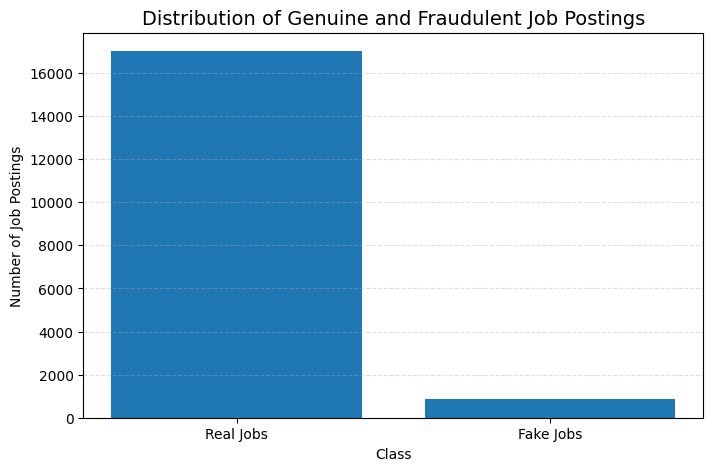

In [7]:
import matplotlib.pyplot as plt

fraud_counts = df["fraudulent"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(["Real Jobs", "Fake Jobs"], fraud_counts)

plt.title("Distribution of Genuine and Fraudulent Job Postings", fontsize=14)

plt.xlabel("Class")

plt.ylabel("Number of Job Postings")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [8]:
### Observation

# - The dataset is highly imbalanced.
# - Genuine jobs account for approximately 95% of the data.
# - Fraudulent jobs make up only about 5%.
# - This imbalance suggests that accuracy alone will not be sufficient for evaluating the model.

In [9]:
df["fraudulent"].value_counts(normalize=True)*100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

In [10]:
## 5. Missing Value Analysis
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
dtype: int64

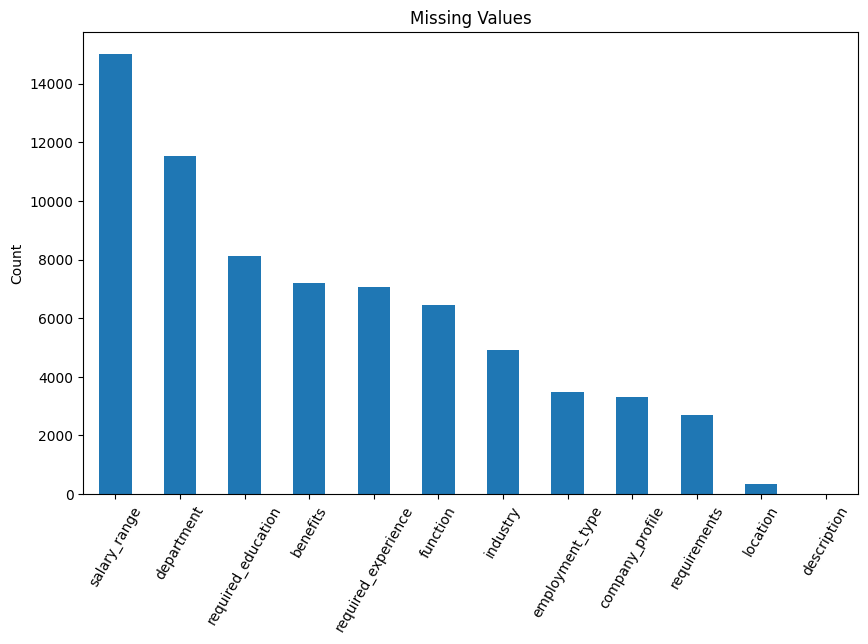

In [11]:
plt.figure(figsize=(10,6))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.show()

In [12]:
## 6. Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
## 7. Target Variable Analysis
df["employment_type"].value_counts()

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [15]:
df["required_education"].value_counts()

required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [16]:
df["required_experience"].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [17]:
df["telecommuting"].value_counts()

telecommuting
0    17113
1      767
Name: count, dtype: int64

In [18]:
df["has_company_logo"].value_counts()

has_company_logo
1    14220
0     3660
Name: count, dtype: int64

In [19]:
df["has_questions"].value_counts()

has_questions
0    9088
1    8792
Name: count, dtype: int64

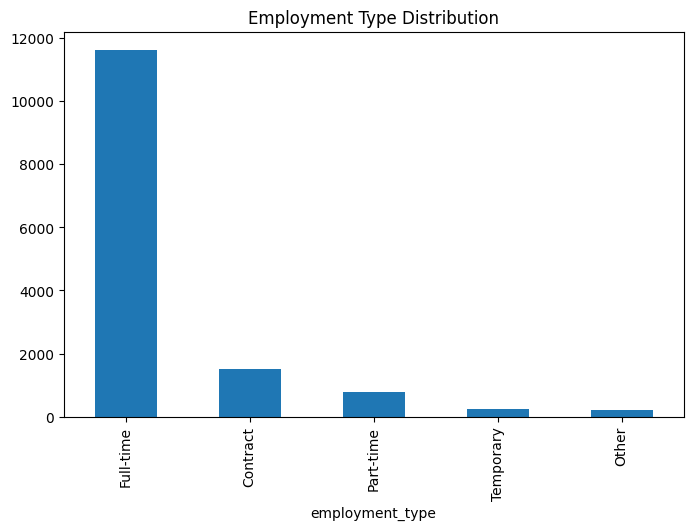

In [20]:
## 8. Employment Type Analysis
df["employment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Employment Type Distribution"
)

plt.show()

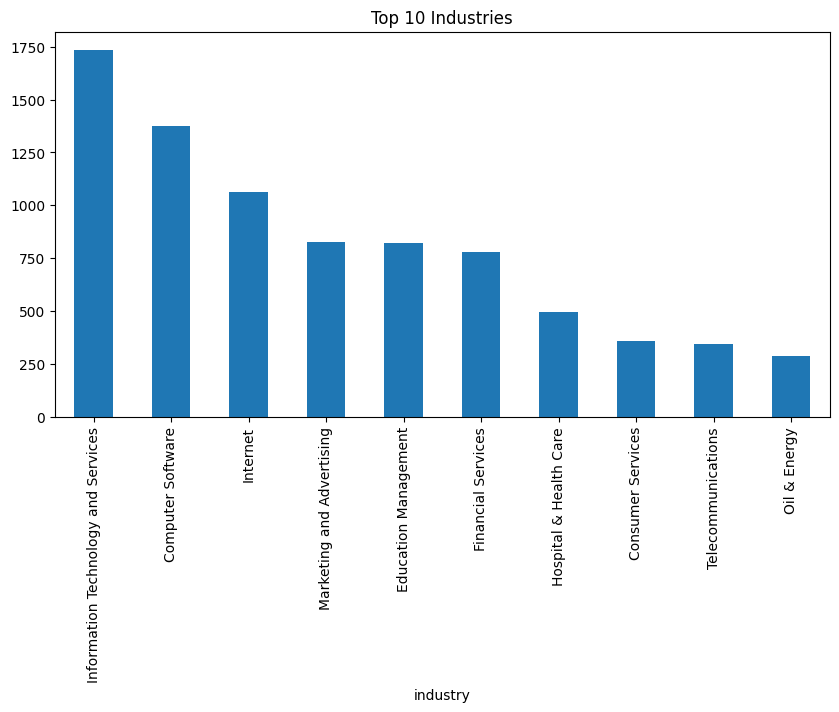

In [21]:
top_industries = df["industry"].value_counts().head(10)

top_industries.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Industries")

plt.show()

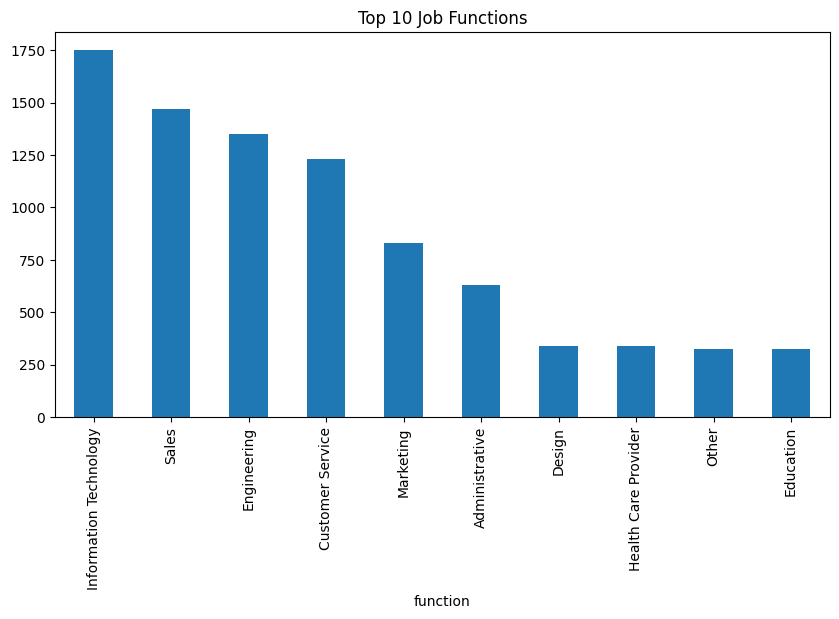

In [22]:
top_functions = df["function"].value_counts().head(10)

top_functions.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Job Functions")

plt.show()

In [23]:
df["country"] = df["location"].str.split(",").str[0]
df["country"].value_counts().head(15)


country
US    10656
GB     2384
GR      940
CA      457
DE      383
NZ      333
IN      276
AU      214
PH      132
NL      127
BE      117
IE      114
SG       80
HK       77
PL       76
Name: count, dtype: int64

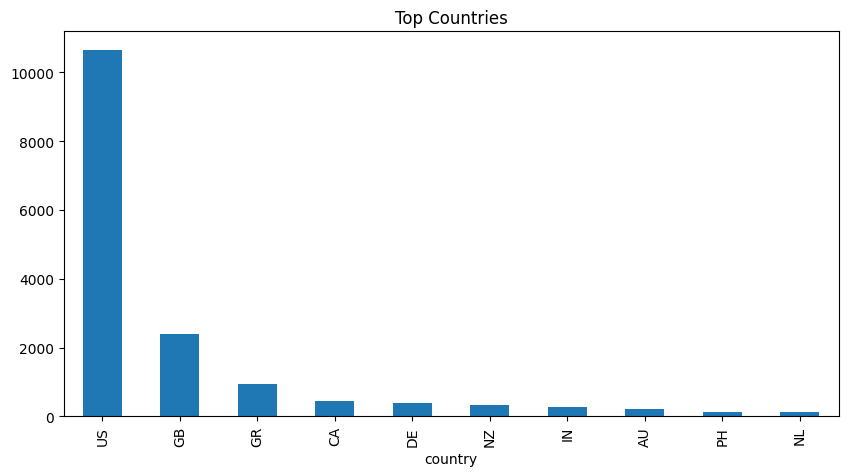

In [24]:
df["country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Countries")

plt.show()

In [25]:
import pandas as pd

pd.crosstab(df["employment_type"], df["fraudulent"])

fraudulent,0,1
employment_type,,
Contract,1480,44
Full-time,11130,490
Other,212,15
Part-time,723,74
Temporary,239,2


In [26]:
pd.crosstab(df["required_education"], df["fraudulent"])

fraudulent,0,1
required_education,,
Associate Degree,268,6
Bachelor's Degree,5045,100
Certification,151,19
Doctorate,25,1
High School or equivalent,1910,170
Master's Degree,385,31
Professional,70,4
Some College Coursework Completed,99,3
Some High School Coursework,7,20


In [27]:
pd.crosstab(df["has_company_logo"], df["fraudulent"])

fraudulent,0,1
has_company_logo,,
0,3077,583
1,13937,283


In [28]:
pd.crosstab(df["telecommuting"], df["fraudulent"])

fraudulent,0,1
telecommuting,,
0,16311,802
1,703,64


In [29]:
df.to_csv("../data/fake_job_cleaned.csv", index=False)

In [30]:
# 9. Data Cleaning & NLP Preprocessing

# In this section, the raw dataset is cleaned and transformed into a format suitable for machine learning. Missing values, HTML tags, URLs, punctuation, stop words, and other unnecessary text are removed before feature extraction.

In [31]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
country                  346
dtype: int64

In [32]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

In [33]:
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "location"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [34]:
df.isnull().sum()

job_id                     0
title                      0
location                   0
department             11547
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
country                  346
dtype: int64

In [35]:
#Observation
# All missing values have been handled.
# Text columns were filled with empty strings while categorical columns were filled with "Unknown".

In [36]:
#Duplicate records were removed to improve data quality.

print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (17880, 19)
After: (17880, 19)


In [37]:
df["text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

In [38]:
df["text"].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: text, dtype: object

In [39]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to C:\Users\MANVENDRA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\MANVENDRA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MANVENDRA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MANVENDRA
[nltk_data]     SINGH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [41]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [42]:
# Build the Text Cleaning Function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords & lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [43]:
# Apply Cleaning
df["clean_text"] = df["text"].apply(clean_text)

In [44]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


In [45]:
# Compare Before & After
print("Original Text:\n")
print(df["text"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Text:\n")
print(df["clean_text"][0])

Original Text:

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and crowd

In [46]:
# Save the Processed Dataset
df.to_csv("../data/fake_job_processed.csv", index=False)

In [47]:
# 10. Feature Engineering

# Machine learning algorithms cannot understand raw text directly. Therefore, the cleaned textual data is converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5
)

In [49]:
X = tfidf.fit_transform(df["clean_text"])

y = df["fraudulent"]
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (17880, 5000)
Target Shape: (17880,)


In [50]:
# 11. Train-Test Split

# The dataset is divided into training and testing subsets. The training data is used for learning the model, while the testing data is used for evaluating its performance.

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (14304, 5000)
Testing Features: (3576, 5000)


In [ ]:
# Import All Models
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.ensemble import RandomForestClassifier



In [53]:
# Train Models

In [54]:
# Logistic Regression
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [55]:
# Naive Bayes
nb = MultinomialNB()

nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
# SVC
from sklearn.svm import SVC
svm = SVC(
    kernel="linear",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)
# svm_pred = svm.predict(X_test)

In [57]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
# Make Predictions
lr_pred = lr.predict(X_test)

nb_pred = nb.predict(X_test)

svm_pred = svm.predict(X_test)

rf_pred = rf.predict(X_test)

In [97]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):
    print("=" * 40)
    print(name)
    print("=" * 40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Naive Bayes", y_test, nb_pred)

evaluate_model("Linear SVM", y_test, svm_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("SVC", y_test, svm_pred)

Logistic Regression
Accuracy : 0.9636465324384788
Precision: 0.5823754789272031
Recall   : 0.8786127167630058
F1 Score : 0.7004608294930875

Naive Bayes
Accuracy : 0.9692393736017897
Precision: 0.8795180722891566
Recall   : 0.42196531791907516
F1 Score : 0.5703125

Linear SVM
Accuracy : 0.9784675615212528
Precision: 0.74
Recall   : 0.8554913294797688
F1 Score : 0.7935656836461126

Random Forest
Accuracy : 0.9784675615212528
Precision: 0.9897959183673469
Recall   : 0.5606936416184971
F1 Score : 0.7158671586715867

SVC
Accuracy : 0.9784675615212528
Precision: 0.74
Recall   : 0.8554913294797688
F1 Score : 0.7935656836461126



In [60]:
# Classification Report of Logistic Regression
from sklearn.metrics import classification_report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.58      0.88      0.70       173

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576



In [61]:
# Classification Report of Naive Bayes
from sklearn.metrics import classification_report
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.88      0.42      0.57       173

    accuracy                           0.97      3576
   macro avg       0.93      0.71      0.78      3576
weighted avg       0.97      0.97      0.96      3576



In [62]:
# Classification Report of Linear SVM
from sklearn.metrics import classification_report
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.74      0.86      0.79       173

    accuracy                           0.98      3576
   macro avg       0.87      0.92      0.89      3576
weighted avg       0.98      0.98      0.98      3576



In [63]:
# Classification Report of Random Forest
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.56      0.72       173

    accuracy                           0.98      3576
   macro avg       0.98      0.78      0.85      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Linear SVM (SVC)"
    ],
    "Accuracy": [
        96.36,
        96.92,
        97.84,
        97.85
    ],
    "Precision": [
        58.24,
        87.95,
        98.98,
        74.00
    ],
    "Recall": [
        87.86,
        42.20,
        56.07,
        85.55
    ],
    "F1 Score": [
        70.04,
        57.03,
        71.58,
        79.36
    ]
})



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,96.36,58.24,87.86,70.04
1,Naive Bayes,96.92,87.95,42.20,57.03
2,Random Forest,97.84,98.98,56.07,71.58
3,Linear SVM (SVC),97.85,74.00,85.55,79.36


In [71]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False
)

plt.title("Model Comparison")

plt.ylabel("F1 Score")

plt.tight_layout()

plt.savefig("../images/model_comparison.png", dpi=300)

plt.close()

In [72]:
# Model Comparison Table
results = []

models = {
    "Logistic Regression": (lr, lr_pred),
    "Naive Bayes": (nb, nb_pred),
    "Linear SVM": (svm, svm_pred),
    "Random Forest": (rf, rf_pred)
}

for name, (_, pred) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)
results_df.to_csv(
    "../artifacts/model_results.csv",
    index=False
)

In [86]:
# Save the Model
import joblib
joblib.dump(svm, "../models/fake_job_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
# model = joblib.load("../models/fake_job_model.pkl")

# vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [87]:
import joblib

joblib.dump(svm, "../models/fake_job_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [84]:
# Save Evaluation Metrics
import json

metrics = {
    "accuracy":97.85,
    "precision":74.00,
    "recall":85.55,
    "f1_score":79.36,
    "best_model":"Linear SVM (SVC)"
}

with open("../artifacts/metrics.json","w") as f:
    json.dump(metrics,f,indent=4)

In [85]:
# Save Dataset Information
dataset_info = {
    "total_jobs":len(df),
    "real_jobs":int((df["fraudulent"]==0).sum()),
    "fake_jobs":int((df["fraudulent"]==1).sum()),
    "features":len(df.columns)
}

with open("../artifacts/dataset_info.json","w") as f:
    json.dump(dataset_info,f,indent=4)

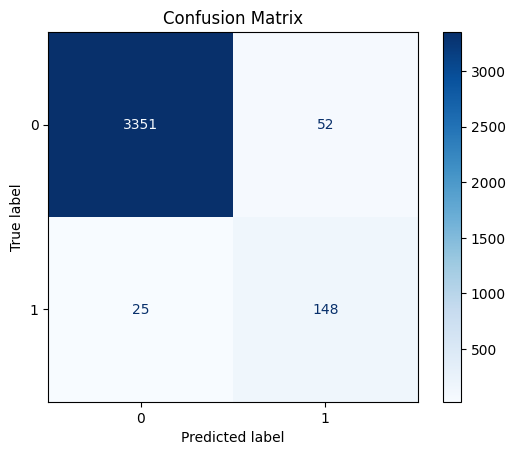

In [93]:
# Save Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png", dpi=300)

plt.show()

In [82]:
# Save Model Comparison Chart
results_df.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("F1 Score")

plt.tight_layout()

plt.savefig(
    "../images/model_comparison.png",
    dpi=300
)

plt.close()

In [83]:
# Save ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.tight_layout()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300
)

plt.close()